Loaded 1024pi.out: angle=0.0°, Fx=3.217e+03, Fy=0.000e+00, components=x, n_points=63
maximum displacement (x): 27.13
sigma_noise added (x): 0.5426 (2.0% of maximum displacement)
realized experimental noise (x): 0.4335
sigma_noise prior: Exp(beta=0.3686)
sigma_bias prior: Exp(beta=0.3686)

l_bias fixed at 0.5
Loaded 512pi.out: angle=0.0°, Fx=1.608e+03, Fy=0.000e+00, components=x, n_points=51
maximum displacement (x): 14.47
sigma_noise added (x): 0.2893 (2.0% of maximum displacement)
realized experimental noise (x): 0.2202
sigma_noise prior: Exp(beta=0.6913)
sigma_bias prior: Exp(beta=0.6913)

l_bias fixed at 0.5
Loaded 256pi.out: angle=0.0°, Fx=8.042e+02, Fy=0.000e+00, components=x, n_points=51
maximum displacement (x): 7.824
sigma_noise added (x): 0.1565 (2.0% of maximum displacement)
realized experimental noise (x): 0.1191
sigma_noise prior: Exp(beta=1.278)
sigma_bias prior: Exp(beta=1.278)

l_bias fixed at 0.5

Joint fit over 3 datasets:
   F=3217  theta=0.0  t_unload=0.2  unbounded 

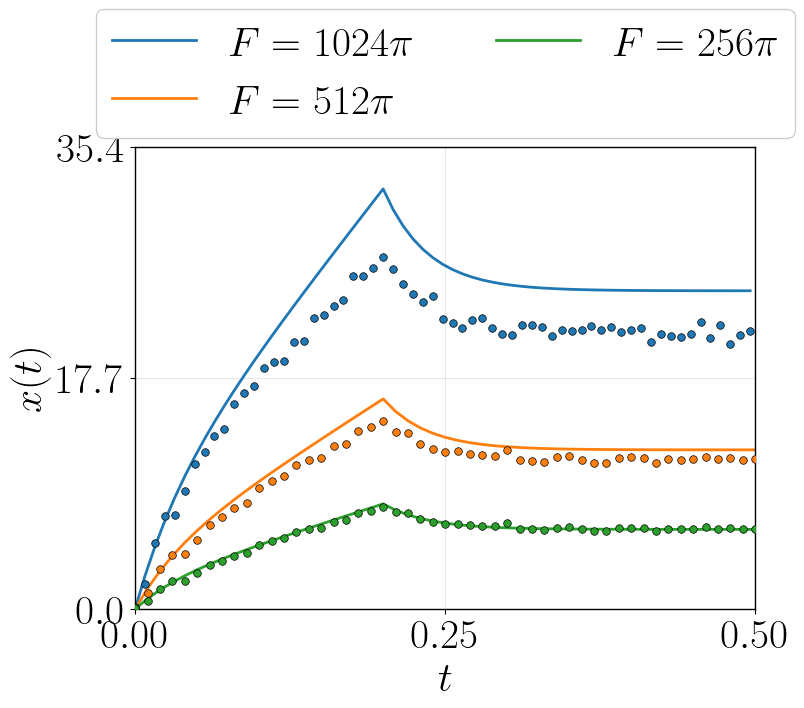

Saved figure: c:\Users\paraj\Documents\bayesian_inference\extras\plots\model_error.pdf


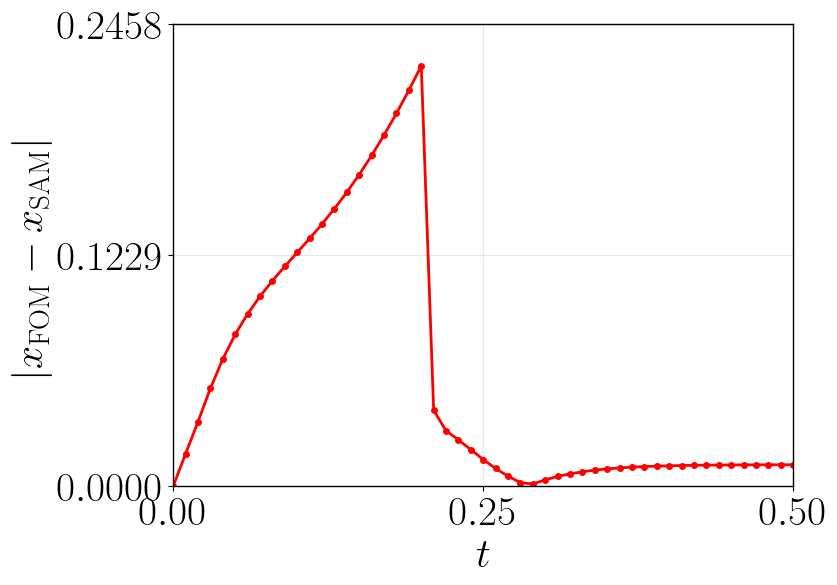

x model error: max |error| = 0.223476, mean |error| = 0.0564039, relative L2 error = 0.0150412

Preparing MCMC: ndim=5, walkers=10, steps=10000, warmup=True

Initial walkers (physical):
  00: [2.74417794 3.82475999 9.65772875 0.68794389 1.53038897]
  01: [ 1.78785845  0.62941647  0.54739584 10.20124625  3.50913436]
  02: [ 0.8267194   1.1357663   1.51246391  2.53409286 14.55601253]
  03: [0.43563421 0.42664619 0.89198393 4.3022368  4.90572306]
  04: [1.01234958 0.08510794 0.13643463 1.5147126  1.37186281]
  05: [1.01391997 0.81734194 6.71806772 7.18960975 1.47510726]
  06: [0.10727832 9.88244827 0.2805225  1.47271162 1.57450447]
  07: [1.427653   1.15100006 0.79252479 0.84556944 6.94361933]
  08: [10.81628493  0.32950068  0.18012479 20.04111073  7.72471728]
  09: [2.93059632 0.32303114 0.88369695 3.75795107 0.76431225]

Warm-up: 1000 steps x 10 walkers


100%|██████████| 1000/1000 [00:07<00:00, 136.82it/s]



Walkers after warm-up (physical):
  00: [0.55381892 1.06547933 0.08937001 0.23476152 0.28440471]
  01: [0.56583934 1.04545852 0.09489649 0.24390508 0.74068271]
  02: [0.56714052 1.04672317 0.09016201 0.27794126 0.45921987]
  03: [0.55200013 1.03199014 0.0983135  0.27773824 0.52226252]
  04: [0.57717374 1.02875332 0.08350144 0.33078769 0.27785584]
  05: [0.55588892 1.08037561 0.09454504 0.3046944  0.28172049]
  06: [0.56068346 1.0623905  0.08604638 0.44387433 0.39891032]
  07: [0.52398682 0.99825173 0.09422019 0.3264427  0.61644695]
  08: [0.5451603  1.02724346 0.10024049 0.23612748 0.38240361]
  09: [0.57387123 1.05683059 0.09745621 0.34749404 0.47286184]


100%|██████████| 10000/10000 [01:05<00:00, 153.69it/s]



MCMC Diagnostics Summary
Chains: 10  |  Samples/chain after burn-in: 7000  |  Total: 70000
------------------------------------------------------------------------------
Parameter              Mean          Std     Rhat    95% CI low   95% CI high
------------------------------------------------------------------------------
eta_s            5.5530e-01   2.7667e-02   1.0036    5.0193e-01    6.1225e-01
eta_p            1.0497e+00   3.5809e-02   1.0025    9.7865e-01    1.1207e+00
lambda_          9.5023e-02   6.2829e-03   1.0025    8.3772e-02    1.0850e-01
sigma_noise      3.0328e-01   2.0040e-02   1.0026    2.6594e-01    3.4476e-01
sigma_bias       6.1392e-01   1.0663e-01   1.0028    4.3539e-01    8.4896e-01
------------------------------------------------------------------------------
Mean Rhat                                               1.0028
Std Rhat                                                0.0004
Saved figure: c:\Users\paraj\Documents\bayesian_inference\extras\plots\corner

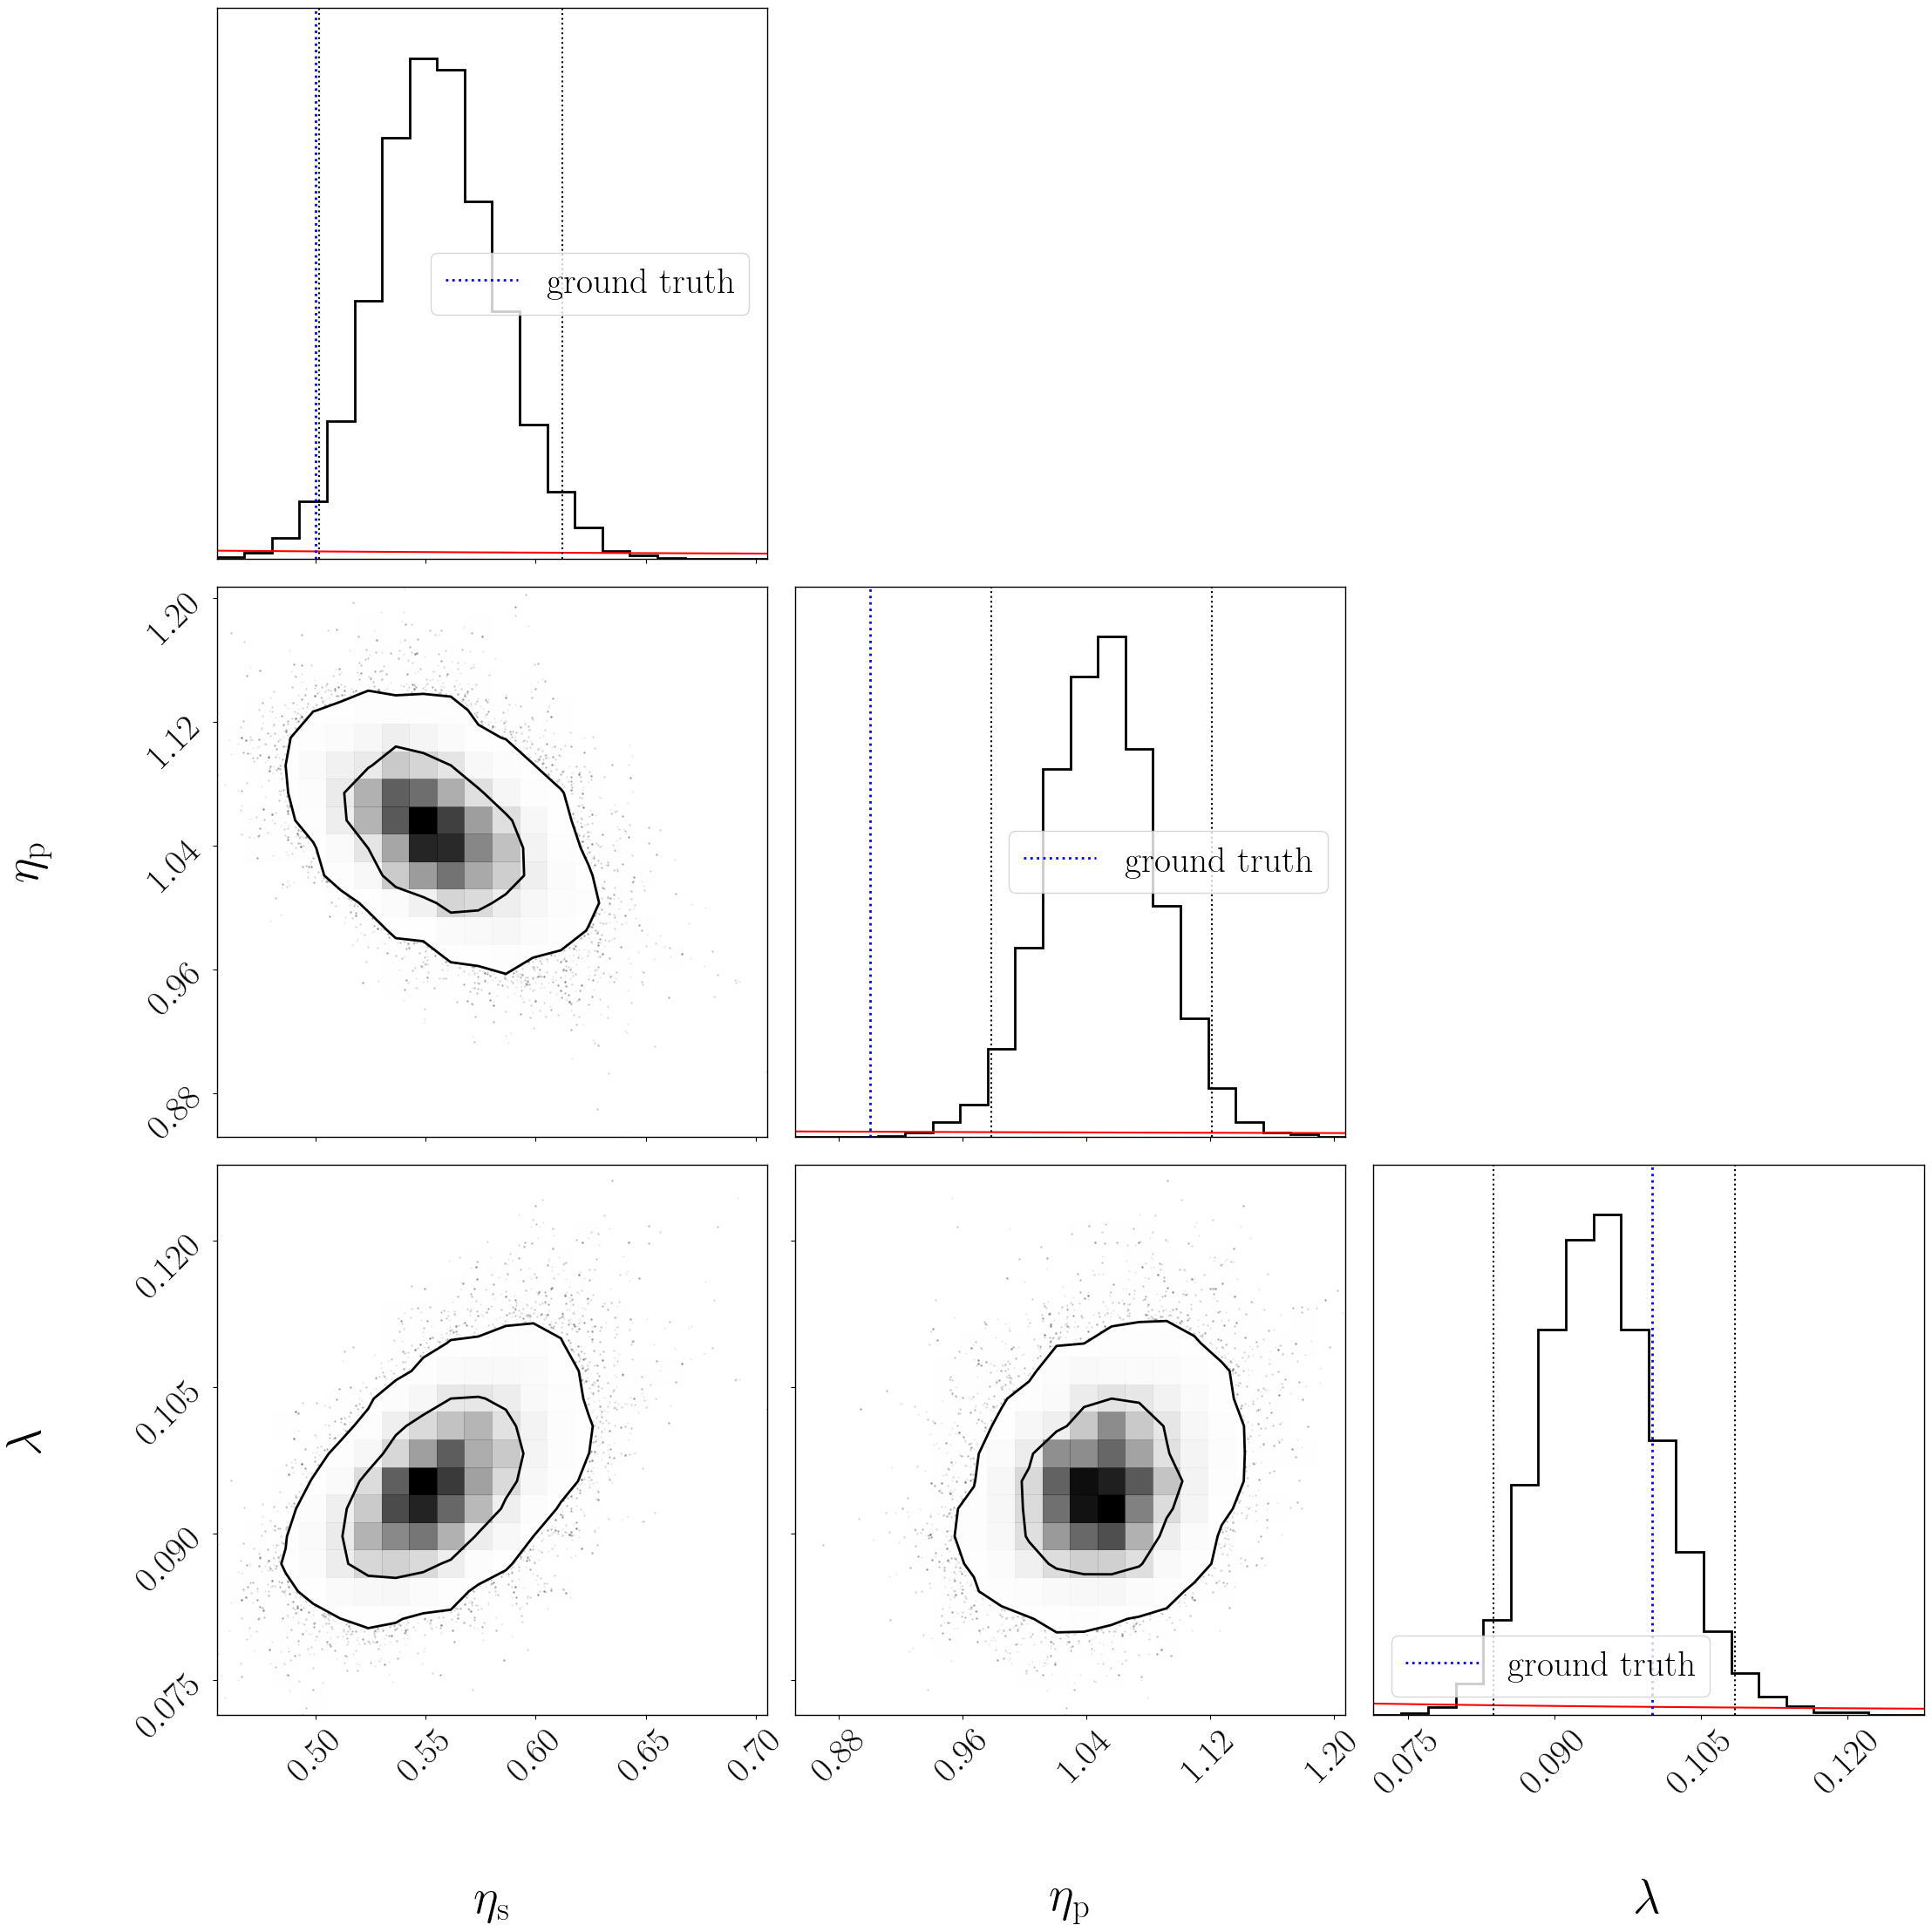

Saved figure: c:\Users\paraj\Documents\bayesian_inference\extras\plots\trace.pdf


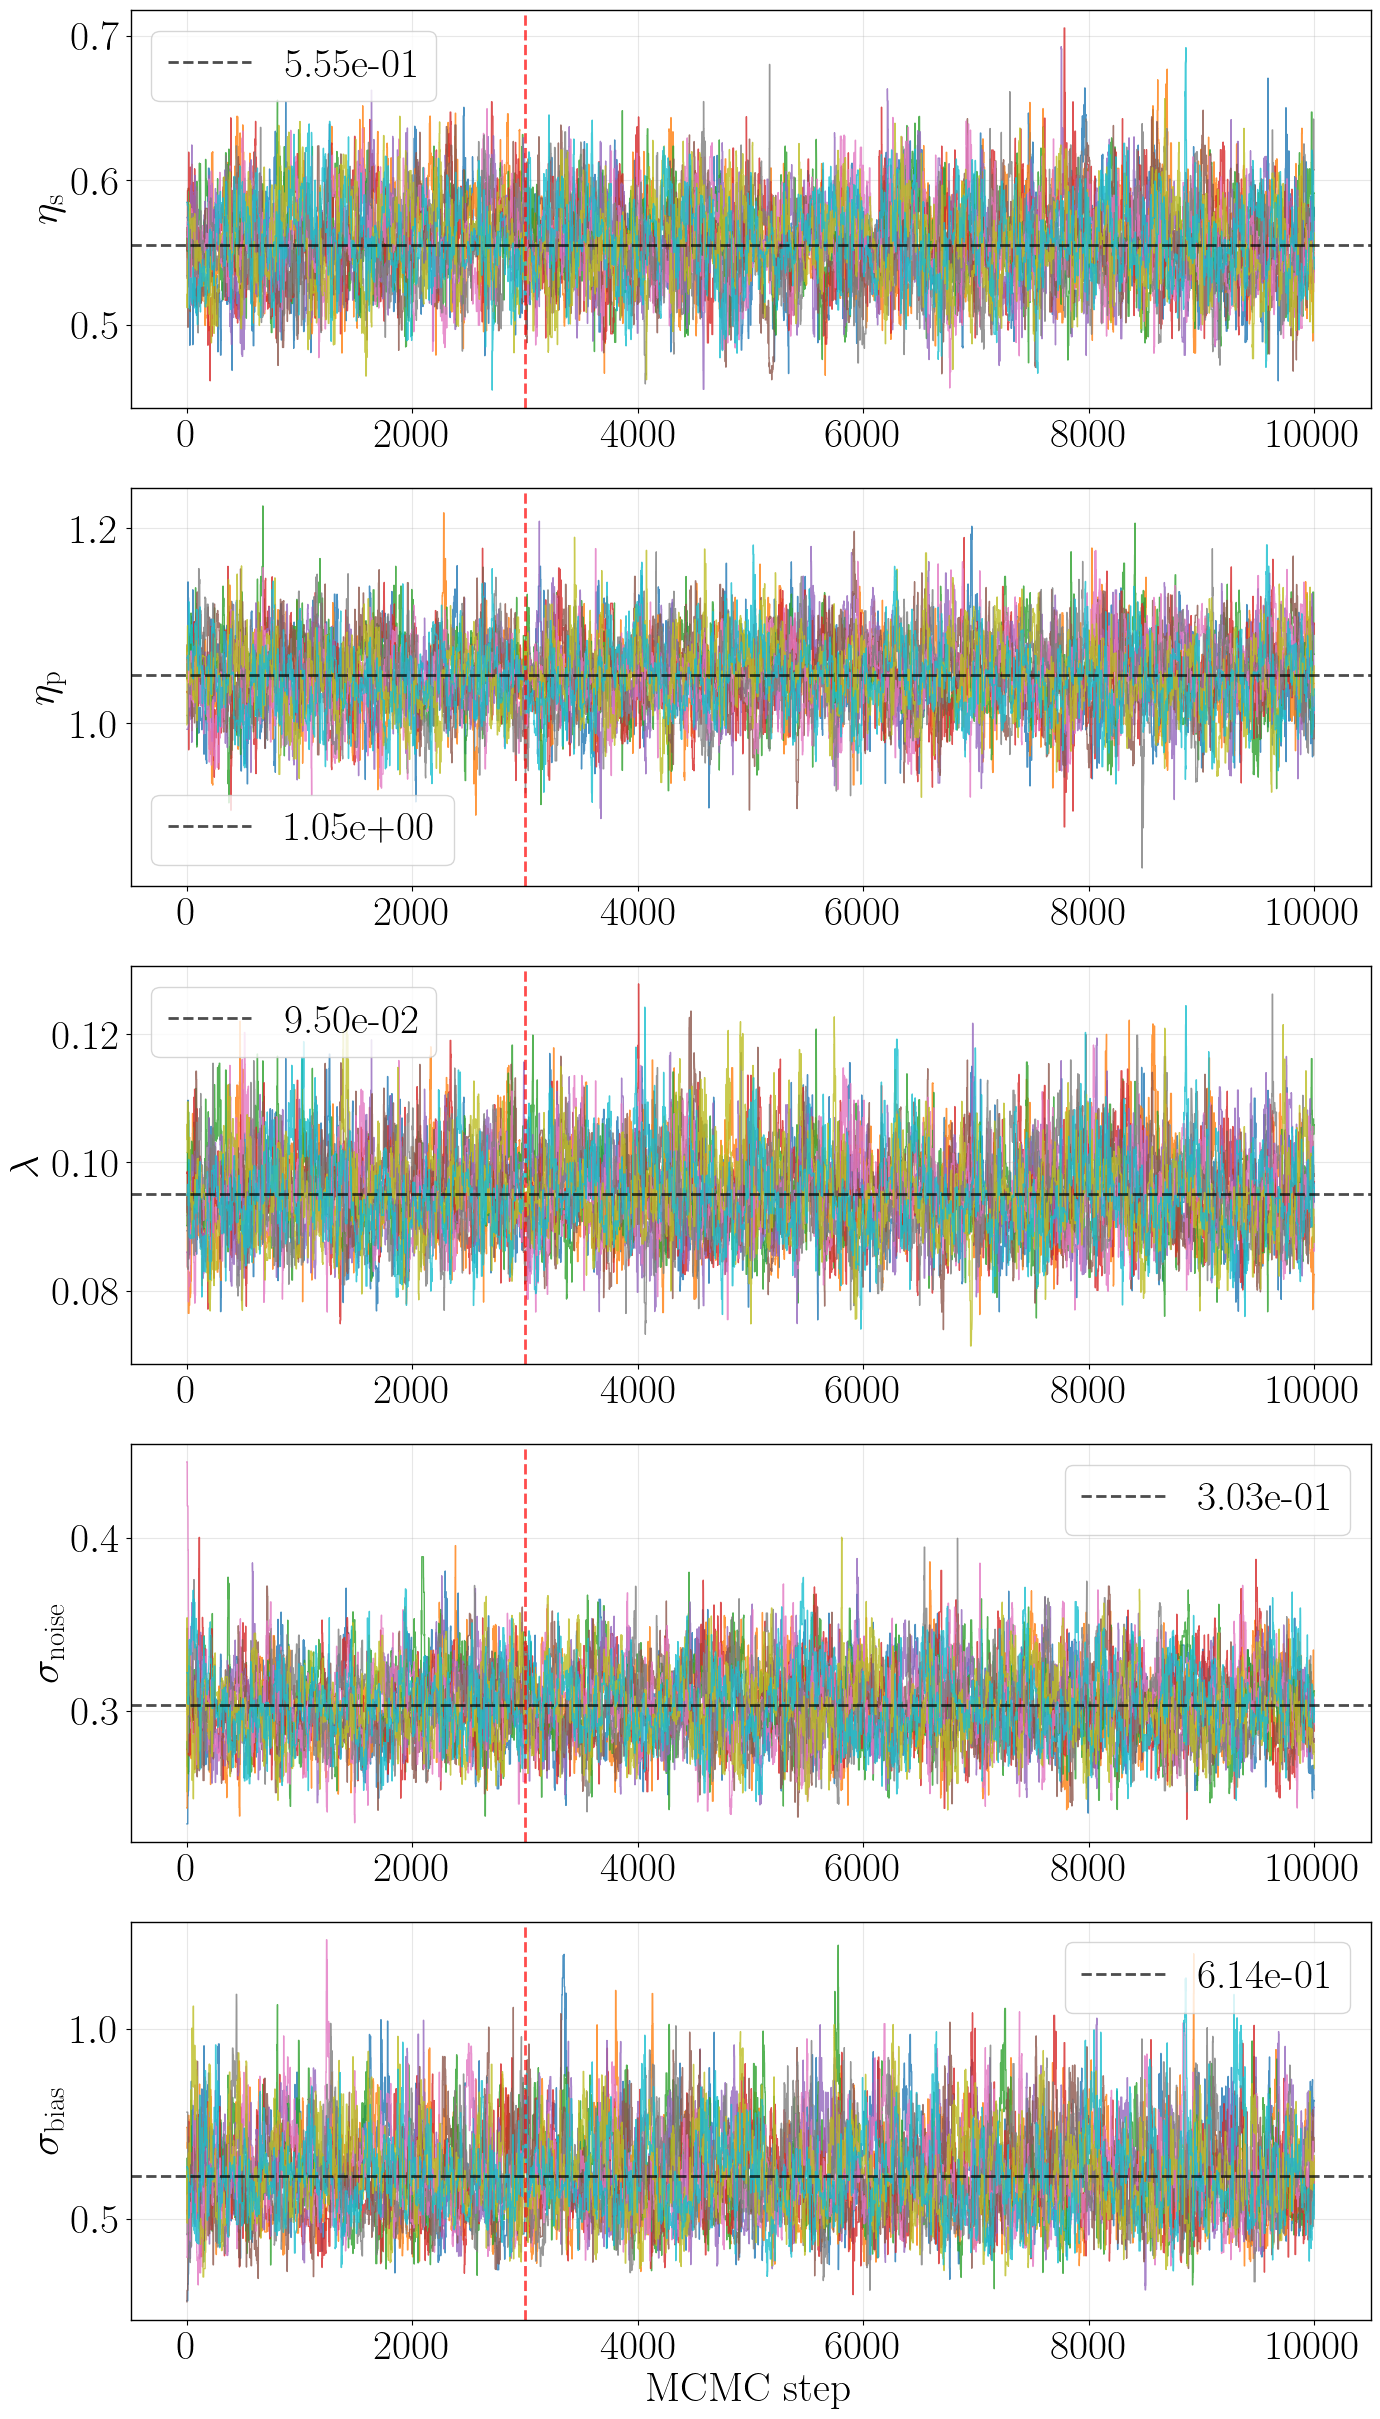

In [ ]:
import os
import sys
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from packages import JointInferenceProcedure

datasets = [
    dict(filename="data/nonlinear_viscoelastic/1024pi.out", force=1024*np.pi, thin_factor=8),
    dict(filename="data/nonlinear_viscoelastic/512pi.out", force=512*np.pi,  thin_factor=2), 
    dict(filename="data/nonlinear_viscoelastic/256pi.out", force=256*np.pi,  thin_factor=2)]

model = JointInferenceProcedure(
    force=8 * np.pi,
    a=1.0,
    theta=0,
    material_model="viscoelastic",
    boundary_model="unbounded",
    sigma_noise_percent=2.0,
    sigma_bias="infer",
    l_bias = 0.5,        
    nsteps=10000,
    thin_factor=1, theta_true = [0.5, 0.9, 0.1])

model.load_datasets(datasets)
model.plot_data()
model.plot_model_error()
samples = model.run_mcmc(warmup=True)
model.plot_results(physical_only = False)


Posterior-predictive coverage (x):
  $F = 1024\pi$           100.0%      0.72      1.62
  $F = 512\pi$            100.0%      1.01      1.93
  $F = 256\pi$            100.0%      1.09      1.67
Saved figure: c:\Users\paraj\Documents\bayesian_inference\extras\plots\posterior_predictive.pdf


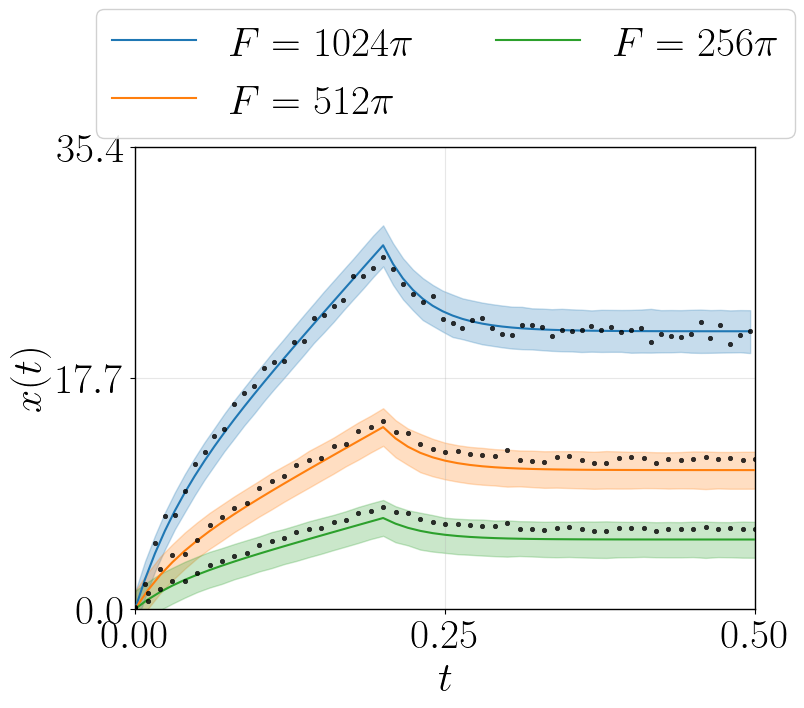

Saved figure: c:\Users\paraj\Documents\bayesian_inference\extras\plots\corner_physical_all.pdf


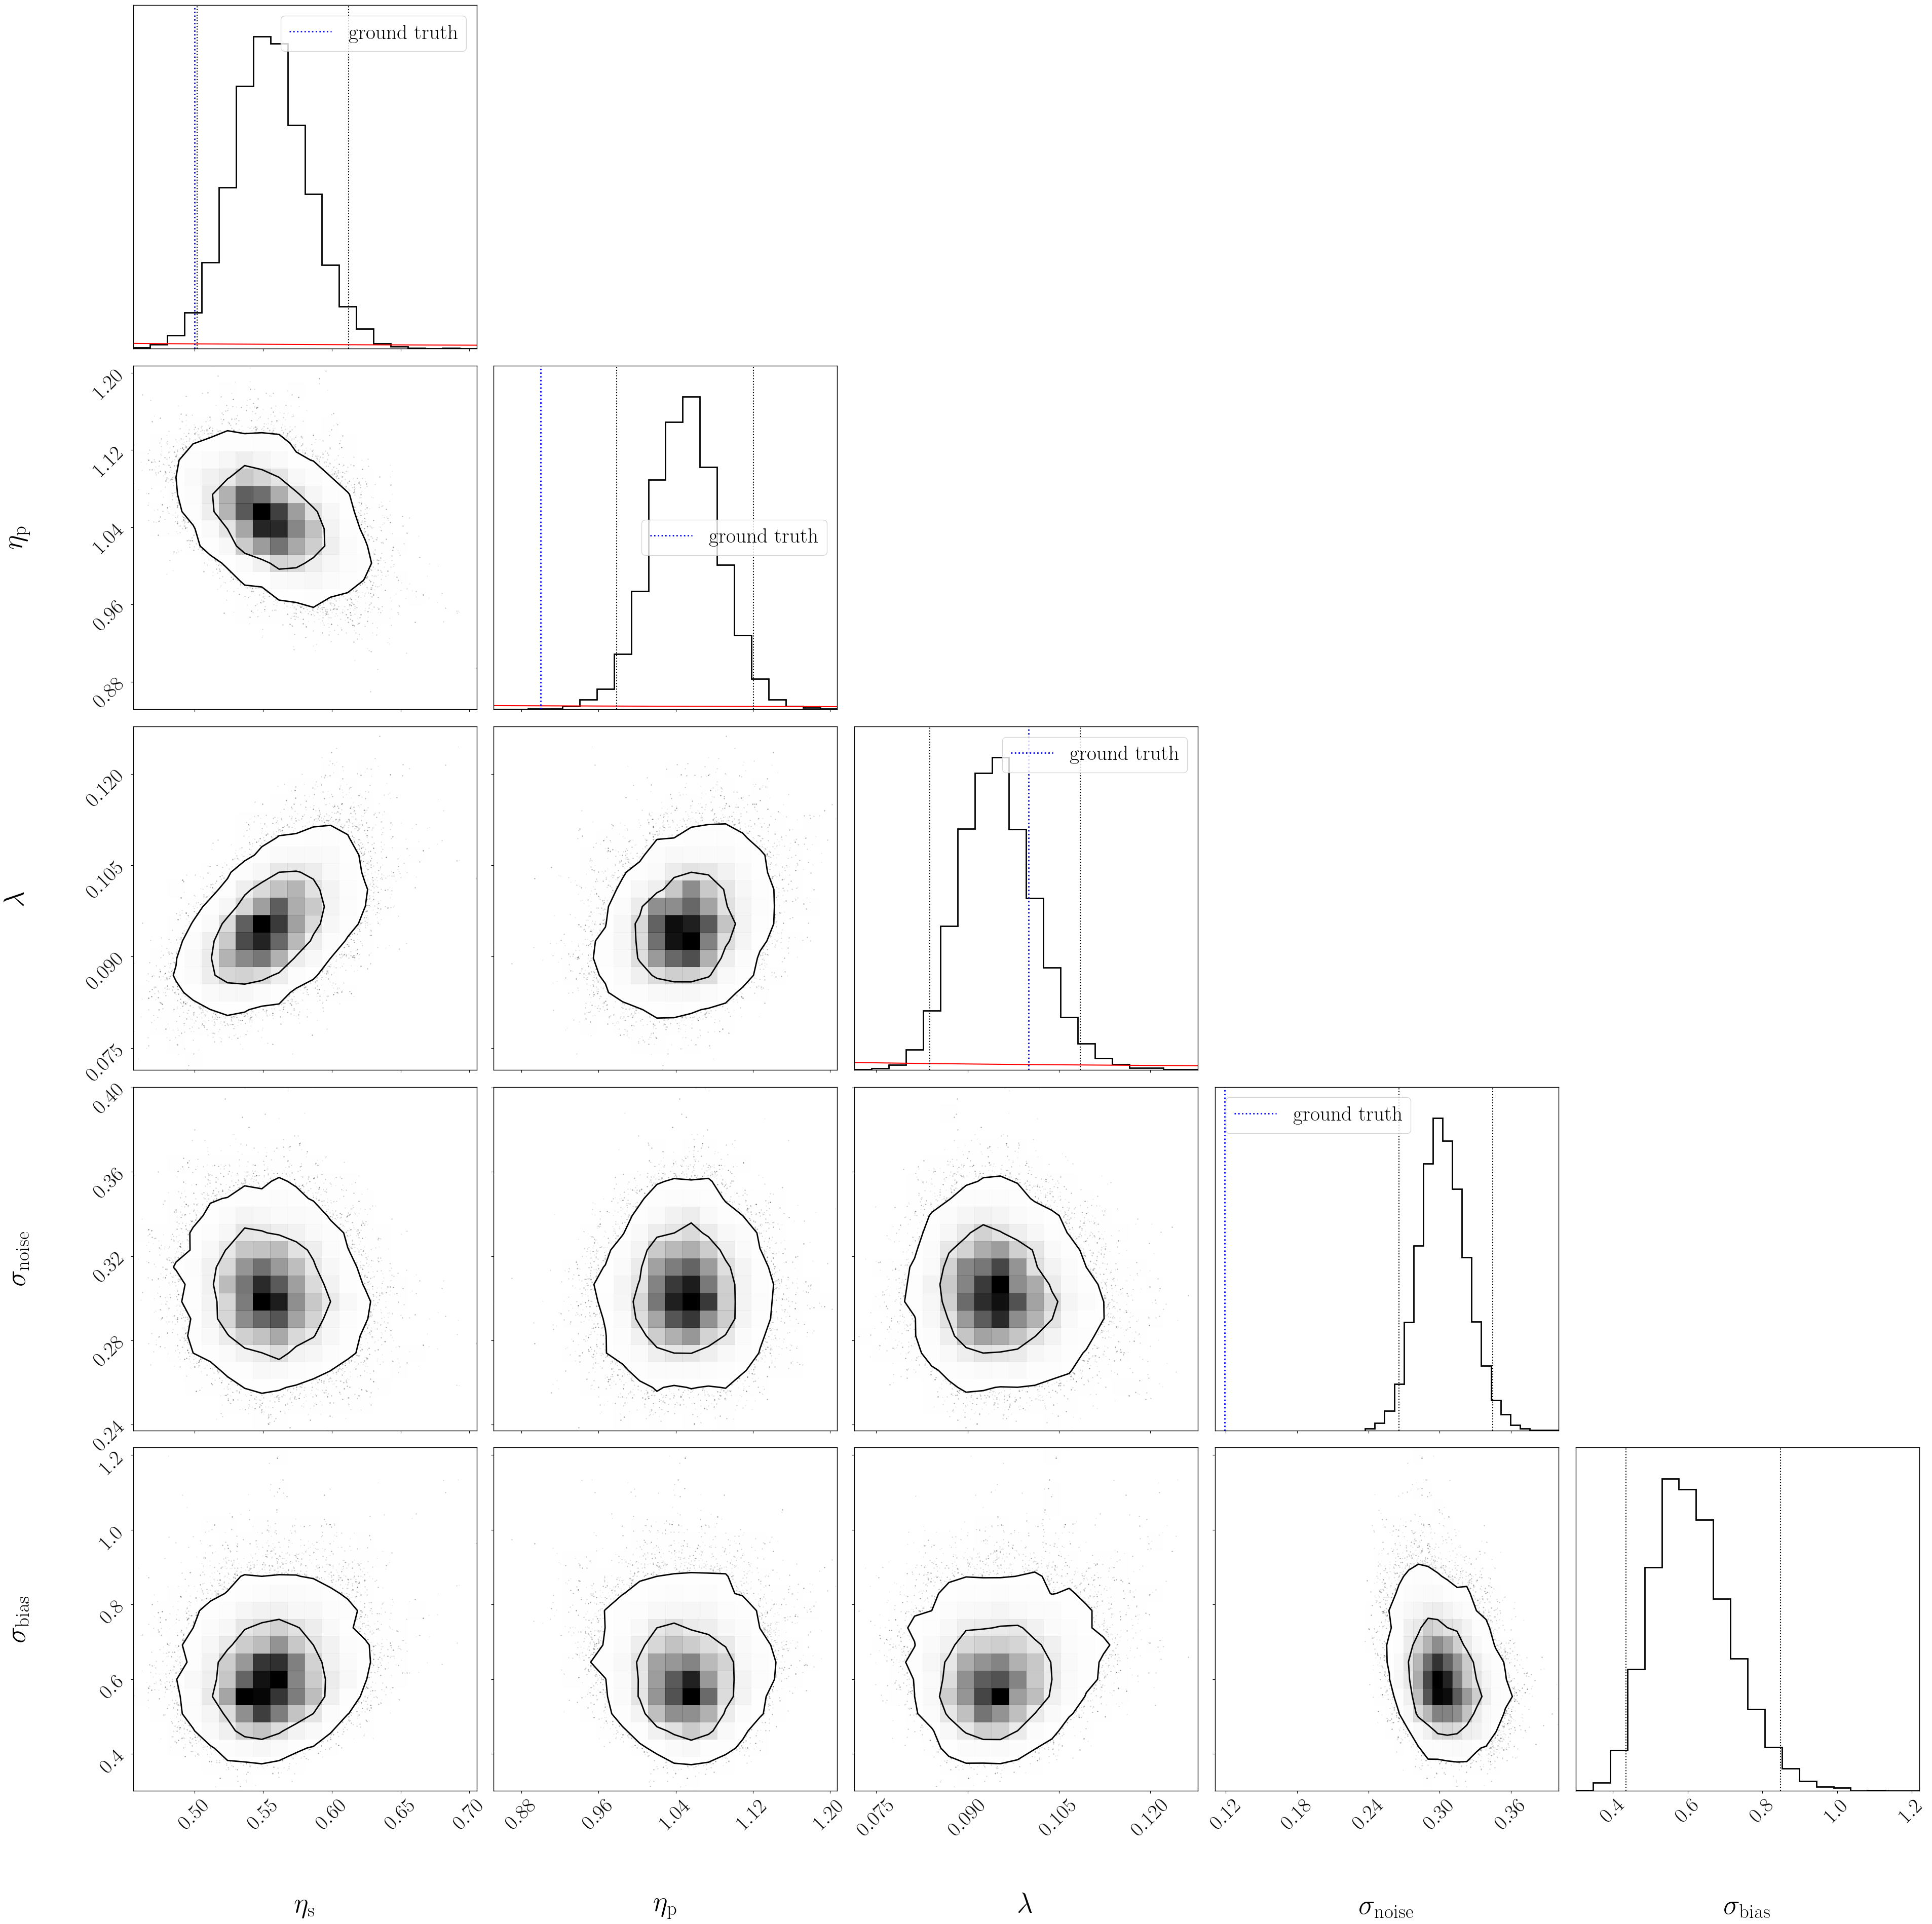

Saved figure: c:\Users\paraj\Documents\bayesian_inference\extras\plots\trace.pdf


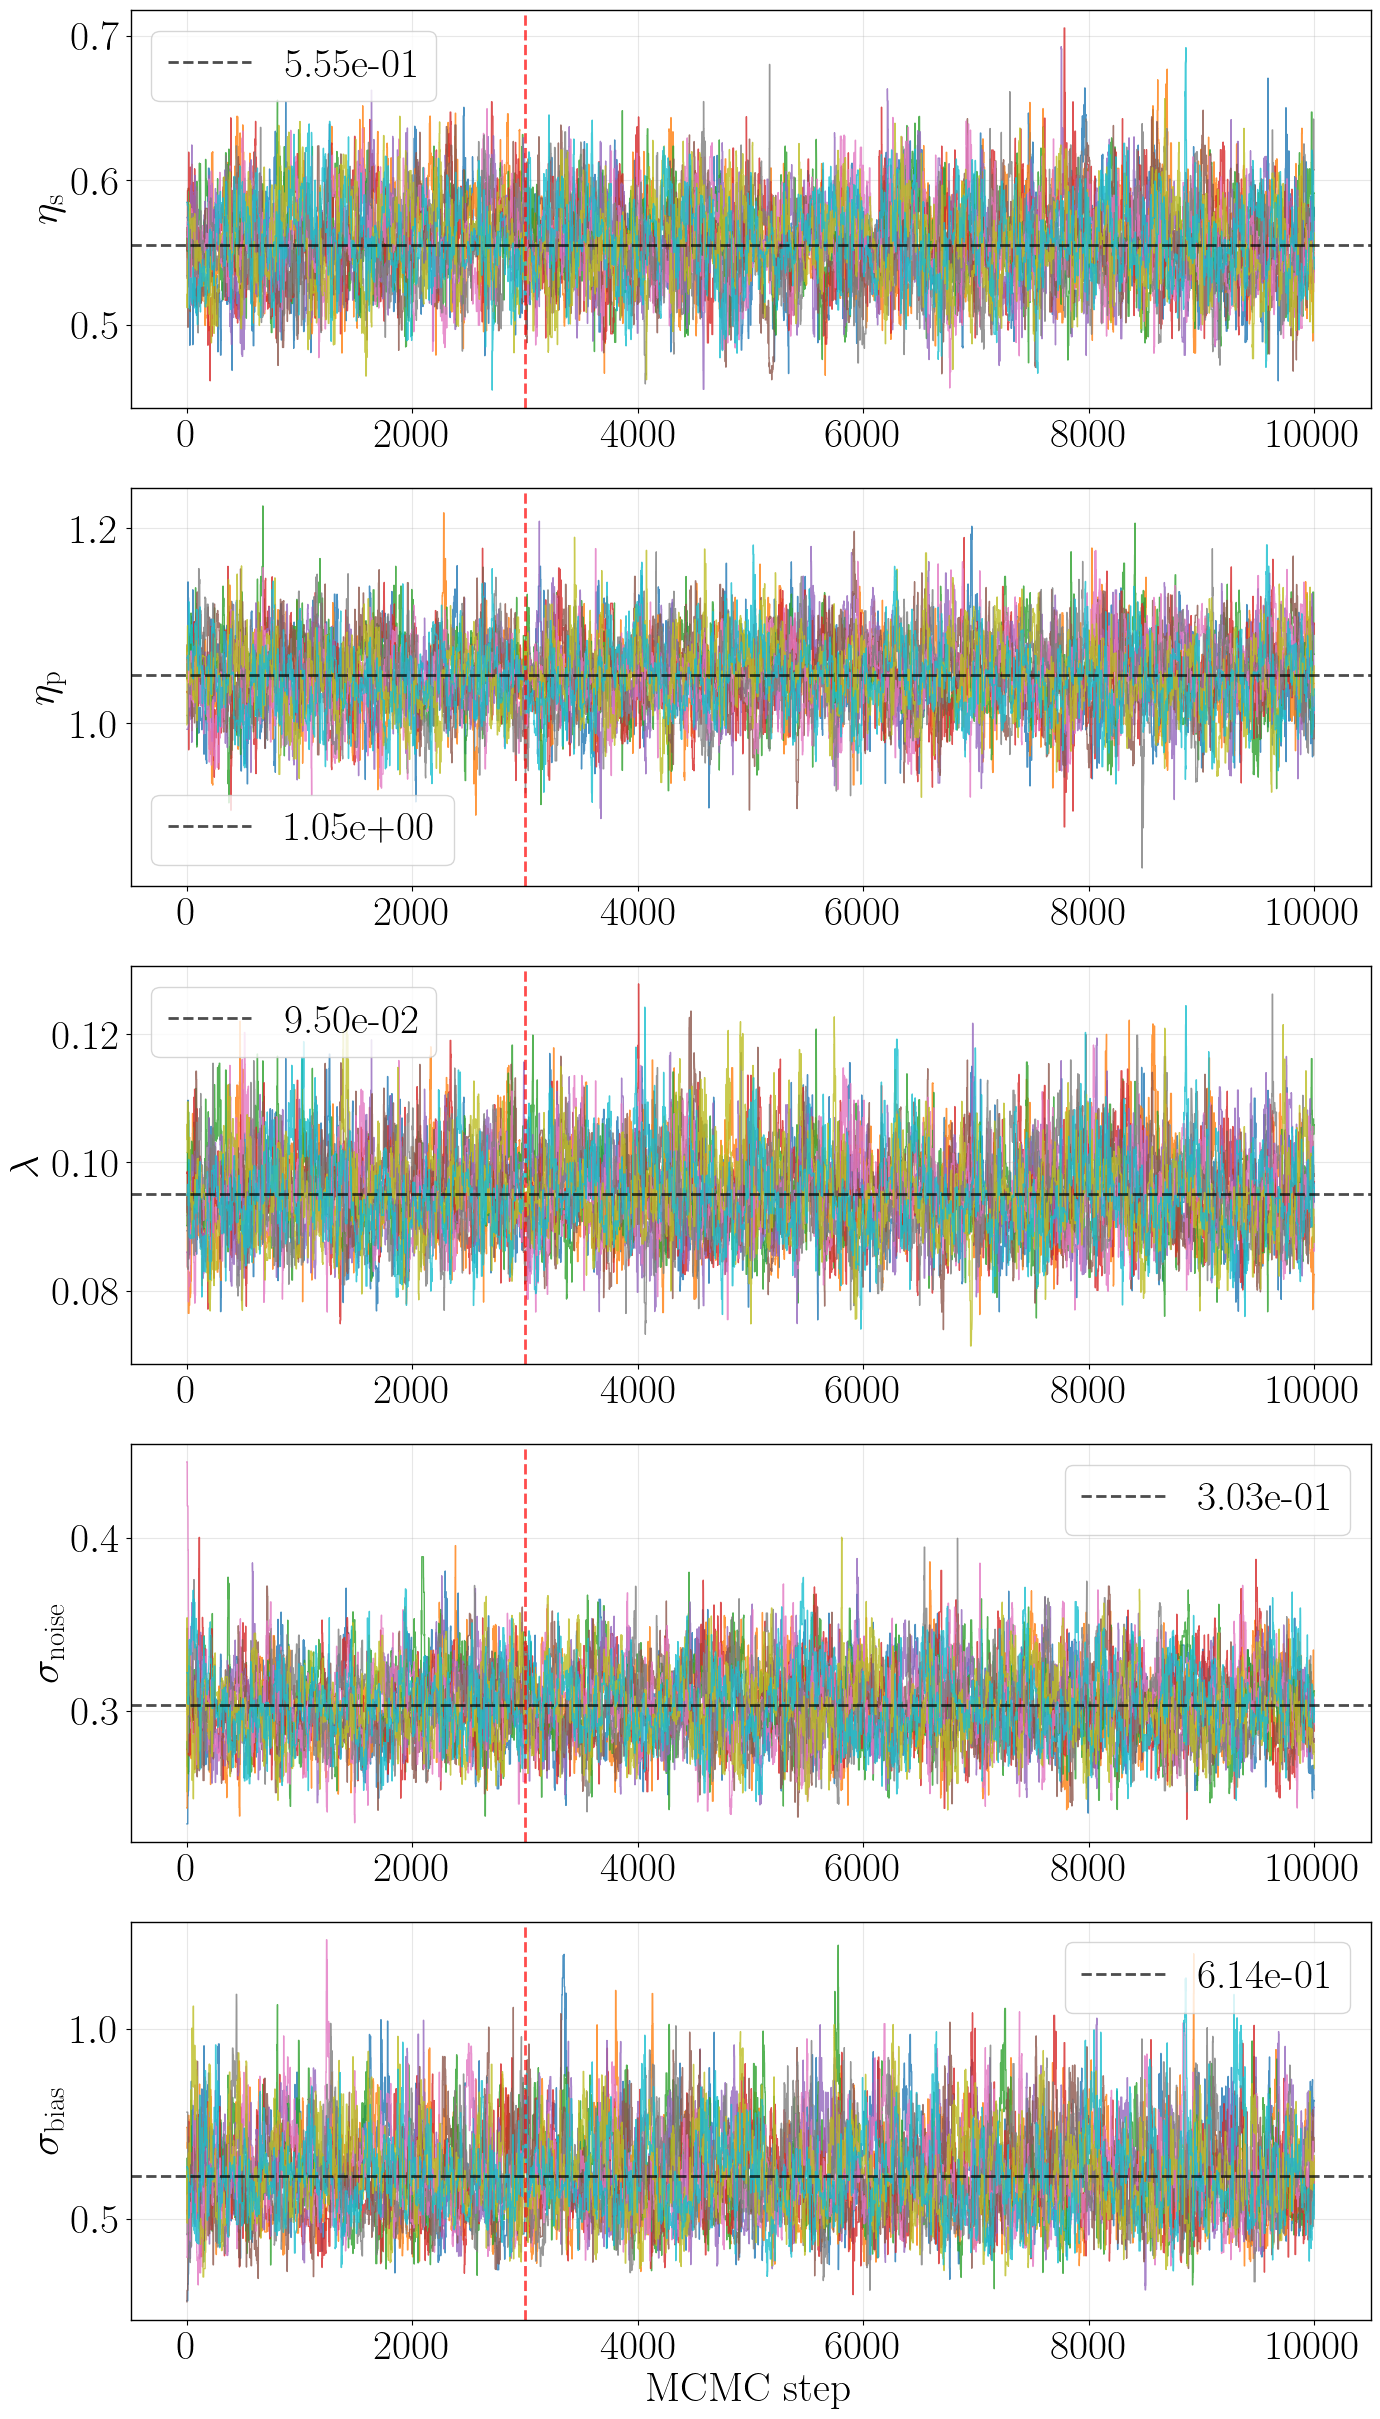

In [2]:
model.plot_results(physical_only = False)